In [1]:
import numpy as np
from torchvision.datasets import CocoDetection
import datetime
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import sys 
sys.path.append("/home/tyfei/cyroem")
import utils
import torch
import importlib 
import json
import modules
import data
importlib.reload(utils)
importlib.reload(modules)
importlib.reload(data)
import torchmetrics

import pycocotools.coco
import pycocotools.mask
import torchvision.transforms.v2 as transforms
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor, DetrForSegmentation, ConditionalDetrForObjectDetection,ConditionalDetrConfig,ConditionalDetrForSegmentation

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
#load model
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/whole_mrc", "epoch=29-total_validate_auroc=0.8853-total_validate_loss=0.2987-v1.ckpt")
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/fold1_mrc", "/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr/fold1_mrc/epoch=39-total_validate_auroc=0.8501-total_validate_loss=0.5736.ckpt")
model = model.eval() 

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([4]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model at stage  stage 1 + 2


/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/utils.py:818: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded v

incompatible parameters ['model.class_labels_classifier.weight', 'model.class_labels_classifier.bias', 'additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight', 'mask_head.inc.double_conv.0.weight', 'mask_head.inc.double_conv.1.weight', 'mask_head.inc.double_conv.1.bias', 'mask_head.inc.double_conv.3.weight', 'mask_head.inc.double_conv.4.we

/home/feity/cryoem/utils.py:856: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters ['mask_head.up6.conv.0.double_conv.3.weight', 'mask_head.up6.conv.0.double_conv.3.bias', 'mask_head.up6.conv.0.double_conv.4.weight', 'mask_head.up6.conv.0.double_conv.4.bias', 'mask_head.up6.emb_layer.0.weight', 'mask_head.up6.emb_layer.0.bias', 'mask_head.outc.weight']
finish loading parameters


In [16]:
# read dataset and run stage 1
model.stage = "stage 1"
# dataset = data.TestDataset("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/24092002_9", norm="hist")
# dataset = data.CocoDetection(
# "/data/transformer_project/transforemer_model/train_data/training/data/",
# "/data/transformer_project/transforemer_model/train_data/training/data/annotations/sllt0039_9_5_10.pkl",
#                             is_npy=True, filter_class=[3, 4, 7, 12, 14], map_class={"3":0, "4":1, "7":2, "12":3, "14":4}, require_mask=True, transform=data.getConstantTransform(), add_classname=True, norm="hist",filtermin=3
# )
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039.pkl",
    norm="hist",
    reshape=800,
    gap=5,
    length_for_average=10,
    transform=data.getConstantTransform(),
    add_classname=True,
    
)
# dataset = data.TestDatasetMrc("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/tomo/sllt0039_9.62Apx.mrc", norm="hist", reshape=800, gap=5, length_for_average=10)
retdict = utils.buildStage2(model, dataset, (800, 800), 0.05, has_none=False, empty=4)
graph = utils.convertStage2Dataset(retdict)

slice 0
check whether reserve  tensor(226) tensor(226)
torch.Size([226]) torch.Size([226, 4])
obj_cnts: 226
slice 1
check whether reserve  tensor(215) tensor(215)
torch.Size([215]) torch.Size([215, 4])
obj_cnts: 441
slice 2
check whether reserve  tensor(228) tensor(228)
torch.Size([228]) torch.Size([228, 4])
obj_cnts: 669
slice 3
check whether reserve  tensor(213) tensor(213)
torch.Size([213]) torch.Size([213, 4])
obj_cnts: 882
slice 4
check whether reserve  tensor(218) tensor(218)
torch.Size([218]) torch.Size([218, 4])
obj_cnts: 1100
slice 5
check whether reserve  tensor(222) tensor(222)
torch.Size([222]) torch.Size([222, 4])
obj_cnts: 1322
slice 6
check whether reserve  tensor(229) tensor(229)
torch.Size([229]) torch.Size([229, 4])
obj_cnts: 1551
slice 7
check whether reserve  tensor(216) tensor(216)
torch.Size([216]) torch.Size([216, 4])
obj_cnts: 1767
slice 8
check whether reserve  tensor(223) tensor(223)
torch.Size([223]) torch.Size([223, 4])
obj_cnts: 1990
slice 9
check whether r

In [17]:
graph

Data(x=[12033, 265], edge_index=[2, 724341], y=[12033], box_masks=[12033], boxes=[12033, 4], edge_label=[724341], sample_mapping=[12033])

In [18]:
# run stage 2
model.stage = "stage 2"
with torch.no_grad():
    res = model(graph.x, graph.edge_index)
z = graph.x[:, [0]]
prob = torch.softmax(res["predict"], 1)
pred_boxes = res["box"]

In [19]:
# concat results from different slices
df = torch.cat([z, pred_boxes, prob], 1)
df = df.detach().numpy()
# df = pd.DataFrame(df, columns=["z", "x", "y", "w", "h", "ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"])
df = pd.DataFrame(df, columns=["z", "x", "y", "w", "h", "ribo",  "mitochondria", "nucleus", "endoplasmic_reticulum_or_Golgi", "None"])
# subdf = df[["ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"]]
subdf = df[["ribo", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"]]
v = subdf.values 
# v = v > np.array([0.6, 0.5, 0.5, 0.5, 0.5, 1.2]) 
v = v > np.array([0.4, 0.5, 0.5, 0.5, 1.2]) 
v = v.any(axis=1) 
df["max"] = subdf.max(axis=1)
df["largest"] = subdf.idxmax(axis=1)
df["prob"] = v    
df

,z,x,y,w,h,ribo,mitochondria,nucleus,endoplasmic_reticulum_or_Golgi,None,max,largest,prob
0,0.268,0.515396,0.065240,0.014263,0.011576,0.475059,0.000187,8.824253e-06,0.000404,0.524341,0.524341,None,True
1,0.268,0.137346,0.162327,0.019011,0.019762,0.826736,0.000126,6.119770e-06,0.000293,0.172839,0.826736,ribo,True
2,0.268,0.271544,0.636184,0.013080,0.007903,0.023891,0.000223,3.215223e-05,0.000082,0.975773,0.975773,None,False
3,0.268,0.261205,0.474824,0.014737,0.014971,0.268454,0.000293,1.331089e-05,0.000473,0.730767,0.730767,None,False
4,0.268,0.389920,0.519732,0.022332,0.021447,0.963993,0.000043,9.071556e-07,0.000695,0.035268,0.963993,ribo,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12028,0.798,0.786203,0.556285,0.011686,0.010246,0.328357,0.000219,1.102987e-05,0.000568,0.670845,0.670845,None,False
12029,0.798,0.878059,0.785513,0.021578,0.023806,0.893113,0.000371,1.739252e-05,0.001452,0.105047,0.893113,ribo,True
12030,0.798,0.615851,0.976221,0.096502,0.044364,0.170506,0.004578,3.637558e-03,0.368530,0.452748,0.452748,None,False
12031,0.798,0.731832,0.281864,0.018212,0.024707,0.052860,0.000972,1.733416e-04,0.000299,0.945695,0.945695,None,False


In [20]:
# run nms
nms = {"ribo":0.2, "microtubule":0.5, "nucleus":0.2, "endoplasmic_reticulum_or_Golgi":0.6, "mitochondria":0.2, "None":1.2}
alldfs = []
for i, subdf in df.groupby(["z", "largest"]):
    # print(subdf.head())
    if i[1] == "None":
        continue
    keep = utils.bbnms(nms[i[1]], utils.convertBoxes(torch.tensor(subdf[["x", "y", "w", "h"]].values)), torch.tensor(subdf["max"].values), subdf["largest"].values)
    # print(i, keep)
    subdf["bbnms"] = False
    subdf.loc[subdf.index[keep.numpy()], "bbnms"] = True
    alldfs.append(subdf)
df = pd.concat(alldfs)
df["final"] = df["bbnms"] & df["prob"]
df["final"].sum()

4138

In [21]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_digits
from scipy.spatial.distance import pdist, squareform

def get_labels(subdf):
    hdb = DBSCAN(min_samples=3, eps = 0.4, metric='precomputed')
    iou = utils.get_iou(subdf[["x", "y", "w", "h"]].values)
    iou = 1 - iou
    mask = subdf["z"].values 
    mask = mask[:, None] == mask[None, :]
    iou[mask] = 2
    mask = subdf["z"].values 
    dis_penalty = np.abs(mask[:, None] - mask[None, :])
    iou = iou + dis_penalty
    hdb.fit(iou)  
    return hdb.labels_
    #subdf["label"] = hdb.labels_
# np.unique(hdb.labels_).tolist()

In [22]:
# run dbscan
afterDBSCAN = [] 
for i, subdf in df.groupby(["largest"]):
    # print(subdf.head())
    if i == "None":
        continue
    subdf = subdf[subdf["final"]]
    if len(subdf) > 0:
        labels = get_labels(subdf)
        subdf["label"] = list(labels)
        afterDBSCAN.append(subdf)

/tmp/ipykernel_3794285/4209089231.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["label"] = list(labels)
/tmp/ipykernel_3794285/4209089231.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["label"] = list(labels)
/tmp/ipykernel_3794285/4209089231.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [23]:
df = pd.concat(afterDBSCAN)
np.unique(df["label"])

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65])

In [33]:
# take one slice and visualize
take = 10
need = []
for i in retdict["sample_mapping"]:
    if retdict["sample_mapping"][i] == take and i in df.index:
        need.append(i)
        
img = retdict["images"][take]
subdf2 = df.loc[need]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
subdf2["label"] = subdf2["label"].astype("str")
# subdf2 = df[subdf2["final"]]
# 
# subdf2["label"] = subdf2["label"].astype("str")

/tmp/ipykernel_3794285/3028601325.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/util

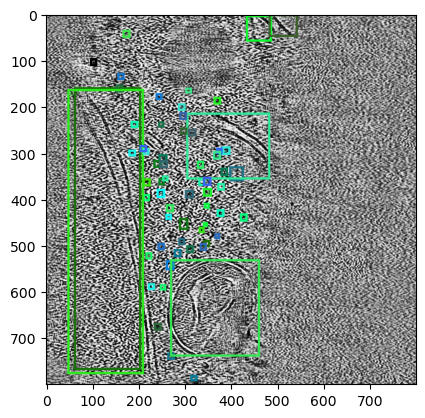

In [34]:
bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": subdf2["label"].values} 
utils.drawannotation(img, labels, font_size=100)

In [ ]:
# prepare for masks
model.stage = "stage mask"
model.eval()

In [ ]:
batch_size = 4
pv = img[None, :, :, :]
allmasks = []
for i in range(0, len(subdf2), batch_size):
    embed = res["embeddings"][subdf2.index[i:i+batch_size]].detach().cpu() 
    boxes = res["box"][subdf2.index[i:i+batch_size]].detach().cpu()
    pv_in = pv.repeat(embed.shape[0], 1, 1, 1)
    in_boxes = boxes.clone()
    # boxes = utils.convertBoxes(torch.tensor(boxes))
    # boxes = torch.tensor(boxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
    with torch.no_grad():
        outputs = model(pixel_values=pv_in.float(), stage_2_embeds=embed.float(), box=in_boxes) 
    
    # t = outputs[0]
    t = torch.sigmoid(outputs)
    t = t.squeeze(1).detach().cpu().numpy()
    allmasks.append(t)
allmasks = np.concatenate(allmasks, 0)

In [45]:
allmasks = np.concatenate(allmasks, 0)

In [47]:
len(subdf2)

21

In [18]:
pv = img[None, :, :, :].repeat(4, 1, 1, 1)
embed = res["embeddings"][subdf2.index[:4]].detach().cpu()

In [19]:
boxes = res["box"][subdf2.index[:4]].detach().cpu()
in_boxes = boxes.clone()
boxes = utils.convertBoxes(torch.tensor(boxes))
boxes = torch.tensor(boxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])

/tmp/ipykernel_2454464/2115447526.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes = utils.convertBoxes(torch.tensor(boxes))
/tmp/ipykernel_2454464/2115447526.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes = torch.tensor(boxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])


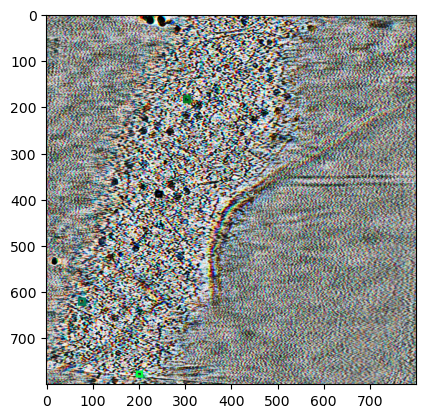

In [20]:
# bboxes = subdf2[["x", "y", "w", "h"]].values

labels = {"bboxes": boxes, "labels": ["test"]*4} 
# img[0] = img[1]
# img[2] = img[1]
utils.drawannotation(img, labels, font_size=100)

In [21]:
pv.shape, embed.shape, boxes.shape

(torch.Size([4, 3, 800, 800]), torch.Size([4, 256]), torch.Size([4, 4]))

In [22]:
model.stage = "stage mask"
model.eval()
with torch.no_grad():
    outputs = model(pixel_values=pv.float(), stage_2_embeds=embed.float(), box=in_boxes)

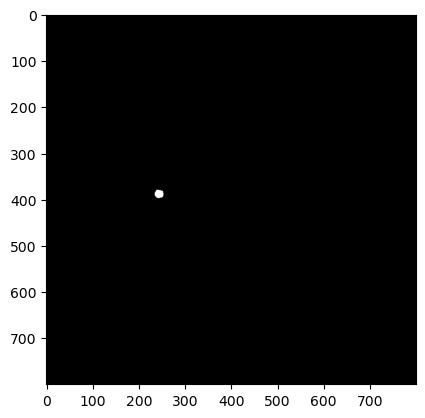

In [23]:
# show one mask
t = outputs[0]
t = torch.sigmoid(t)
plt.imshow(t > 0.3, cmap="gray")

masks


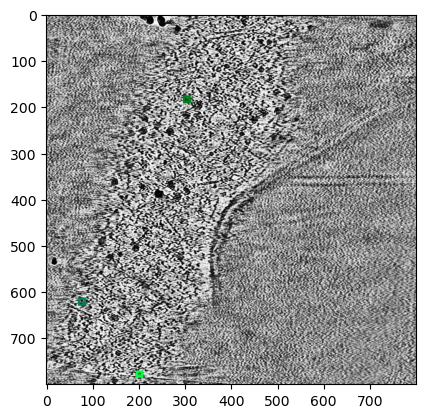

In [24]:
# bboxes = subdf2[["x", "y", "w", "h"]].values
t = outputs.detach().cpu()
labels = {"bboxes": boxes, "labels": ["test"]*4, "masks": t > 0.25, "class_labels":[0, 1, 2, 3]} 
img[0] = img[1]
img[2] = img[1]
utils.drawannotation(img, labels, font_size=100)

In [25]:
# show all four masks
THRES=0.3
q = torch.zeros((800, 800)) 
t = outputs[0].detach()
t = torch.sigmoid(t)
q = q + t > THRES
t = outputs[1].detach()
t = torch.sigmoid(t)
q = q + t > THRES
t = outputs[2].detach()
t = torch.sigmoid(t)
q = q + t > THRES
t = outputs[3].detach()
t = torch.sigmoid(t)
q = q + t > THRES
q = q.unsqueeze(0).repeat(3, 1, 1)  

masks


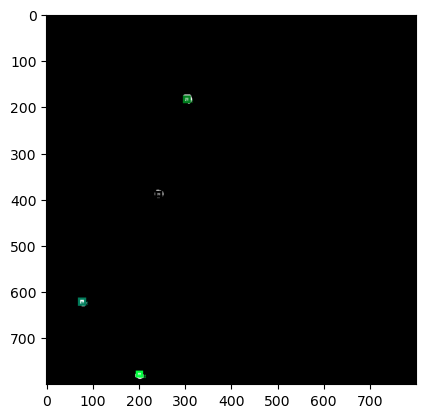

In [26]:
q = q.float()
utils.drawannotation(q, labels, font_size=100)